## Saliency-Based Region-Adaptive Image Compression

This notebook demonstrates:
1. Baseline JPEG-style compression
2. Saliency-driven adaptive quantization
3. Sparsity and frequency-domain analysis as a proxy for bitrate reduction


In [ ]:
!pip install opencv-python-headless scikit-image matplotlib numpy


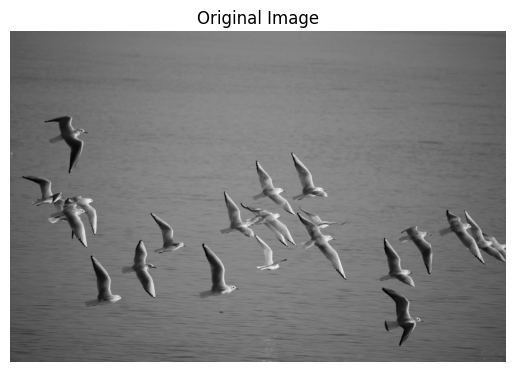

In [ ]:
import cv2
import matplotlib.pyplot as plt
from src.utils import pad_to_block_size

img = cv2.imread(
    '/content/saliency-image-compression/images/sample1.jpg',
    cv2.IMREAD_GRAYSCALE
)

img_padded = pad_to_block_size(img)

plt.imshow(img_padded, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()


Baseline PSNR: 45.26025395600203
Baseline SSIM: 0.9820405735267146


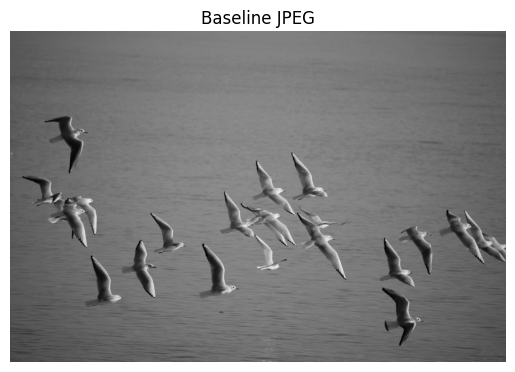

In [ ]:
from src.adaptive_compression import baseline_compress, evaluate

baseline_recon = baseline_compress(img_padded)

p_b, s_b = evaluate(img_padded, baseline_recon)
print("Baseline PSNR:", p_b)
print("Baseline SSIM:", s_b)

plt.imshow(baseline_recon, cmap='gray')
plt.title("Baseline JPEG")
plt.axis('off')
plt.show()


Adaptive PSNR: 38.65806195149198
Adaptive SSIM: 0.9409286088320273


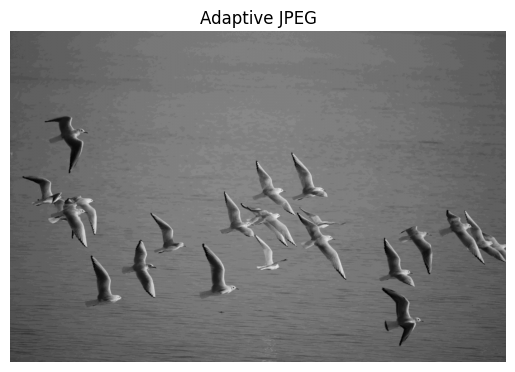

In [ ]:
from src.adaptive_compression import adaptive_compress

adaptive_recon = adaptive_compress(img_padded)

p_a, s_a = evaluate(img_padded, adaptive_recon)
print("Adaptive PSNR:", p_a)
print("Adaptive SSIM:", s_a)

plt.imshow(adaptive_recon, cmap='gray')
plt.title("Adaptive JPEG")
plt.axis('off')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.adaptive_compression import adaptive_compress, evaluate

thresholds = [0.2, 0.3, 0.4, 0.5]
psnr_vals = []
ssim_vals = []

for t in thresholds:
    recon = adaptive_compress(img_padded, threshold=t)
    p, s = evaluate(img_padded, recon)
    psnr_vals.append(p)
    ssim_vals.append(s)
    print(f"Threshold {t}: PSNR={p:.2f}, SSIM={s:.3f}")


Threshold 0.2: PSNR=39.32, SSIM=0.947
Threshold 0.3: PSNR=38.86, SSIM=0.943
Threshold 0.4: PSNR=38.49, SSIM=0.939
Threshold 0.5: PSNR=38.30, SSIM=0.937


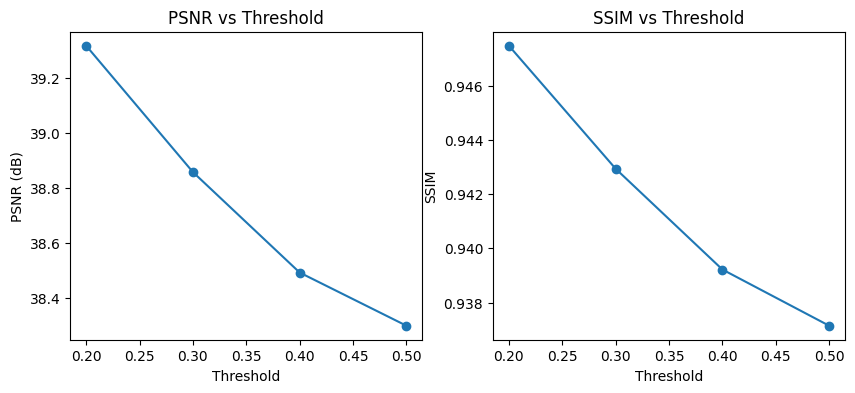

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(thresholds, psnr_vals, marker='o')
plt.title("PSNR vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("PSNR (dB)")

plt.subplot(1,2,2)
plt.plot(thresholds, ssim_vals, marker='o')
plt.title("SSIM vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("SSIM")

plt.show()


In [ ]:
import cv2
from src.utils import pad_to_block_size

image_paths = [
    '/content/saliency-image-compression/images/sample1.jpg',
    '/content/saliency-image-compression/images/sample2.jpg',
    '/content/saliency-image-compression/images/sample3.png',
    '/content/saliency-image-compression/images/sample4.jpg',
]

threshold = 0.35

for path in image_paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img_padded = pad_to_block_size(img)

    baseline = baseline_compress(img_padded)
    adaptive = adaptive_compress(img_padded, threshold=threshold)

    p_b, s_b = evaluate(img_padded, baseline)
    p_a, s_a = evaluate(img_padded, adaptive)

    print(f"\nImage: {path.split('/')[-1]}")
    print(f"Baseline: PSNR={p_b:.2f}, SSIM={s_b:.3f}")
    print(f"Adaptive: PSNR={p_a:.2f}, SSIM={s_a:.3f}")



Image: sample1.jpg
Baseline: PSNR=45.26, SSIM=0.982
Adaptive: PSNR=38.66, SSIM=0.941

Image: sample2.jpg
Baseline: PSNR=35.44, SSIM=0.952
Adaptive: PSNR=32.17, SSIM=0.904

Image: sample3.png
Baseline: PSNR=30.05, SSIM=0.813
Adaptive: PSNR=27.64, SSIM=0.654

Image: sample4.jpg
Baseline: PSNR=35.66, SSIM=0.951
Adaptive: PSNR=31.03, SSIM=0.901


In [ ]:
from src.analysis.sparsity import (
    quantized_coeffs_baseline,
    quantized_coeffs_adaptive,
    zero_ratio
)

from src.analysis.frequency import (
    get_quantized_dct_blocks,
    analyze_subbands_qd
)


In [ ]:
image_paths = [
    'images/sample1.jpg',
    'images/sample2.jpg',
    'images/sample2.png',
    'images/sample4.jpg',
]

threshold = 0.35

print("Sparsity (Zero Ratio) Comparison")
print("--------------------------------")
for path in image_paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Image is not found): {path}")
        continue

    img_padded = pad_to_block_size(img)

    q_base = quantized_coeffs_baseline(img_padded)
    q_adap = quantized_coeffs_adaptive(img_padded, threshold=threshold)

    zr_base_all = zero_ratio(q_base, exclude_dc=False)
    zr_adap_all = zero_ratio(q_adap, exclude_dc=False)

    zr_base_ac = zero_ratio(q_base, exclude_dc=True)
    zr_adap_ac = zero_ratio(q_adap, exclude_dc=True)

    print(f"\nImage: {path.split('/')[-1]}")
    print(f"Baseline zero% (all): {zr_base_all*100:.2f}%   | Adaptive zero% (all): {zr_adap_all*100:.2f}%")
    print(f"Baseline zero% (AC ): {zr_base_ac*100:.2f}%   | Adaptive zero% (AC ): {zr_adap_ac*100:.2f}%")

Sparsity (Zero Ratio) Comparison
--------------------------------

Image: sample1.jpg
Baseline zero% (all): 94.95%   | Adaptive zero% (all): 97.61%
Baseline zero% (AC ): 94.95%   | Adaptive zero% (AC ): 97.61%

Image: sample2.jpg
Baseline zero% (all): 92.13%   | Adaptive zero% (all): 95.57%
Baseline zero% (AC ): 92.13%   | Adaptive zero% (AC ): 95.57%
Image is not found): /content/saliency-image-compression/images/sample3.jpg

Image: sample4.jpg
Baseline zero% (all): 90.62%   | Adaptive zero% (all): 94.95%
Baseline zero% (AC ): 90.61%   | Adaptive zero% (AC ): 94.91%


In [ ]:
qd_baseline = get_quantized_dct_blocks(img_padded, mode="baseline")
qd_adaptive = get_quantized_dct_blocks(img_padded, mode="adaptive", threshold=0.35)
qd_adaptive_freq = get_quantized_dct_blocks(img_padded, mode="adaptive_freq", threshold=0.35)

print("Baseline QD:", analyze_subbands_qd(qd_baseline))
print("Adaptive QD:", analyze_subbands_qd(qd_adaptive))
print("Adaptive + Frequency QD:", analyze_subbands_qd(qd_adaptive_freq))


Baseline QD: {'low': np.float64(0.5917679142987786), 'mid': np.float64(0.9840739107714419), 'high': np.float64(0.9996522528764592)}
Adaptive QD: {'low': np.float64(0.7317427656933833), 'mid': np.float64(0.9968103496542651), 'high': np.float64(0.9999606324011086)}
Adaptive + Frequency QD: {'low': np.float64(0.7317427656933833), 'mid': np.float64(0.9986370062428266), 'high': np.float64(1.0)}


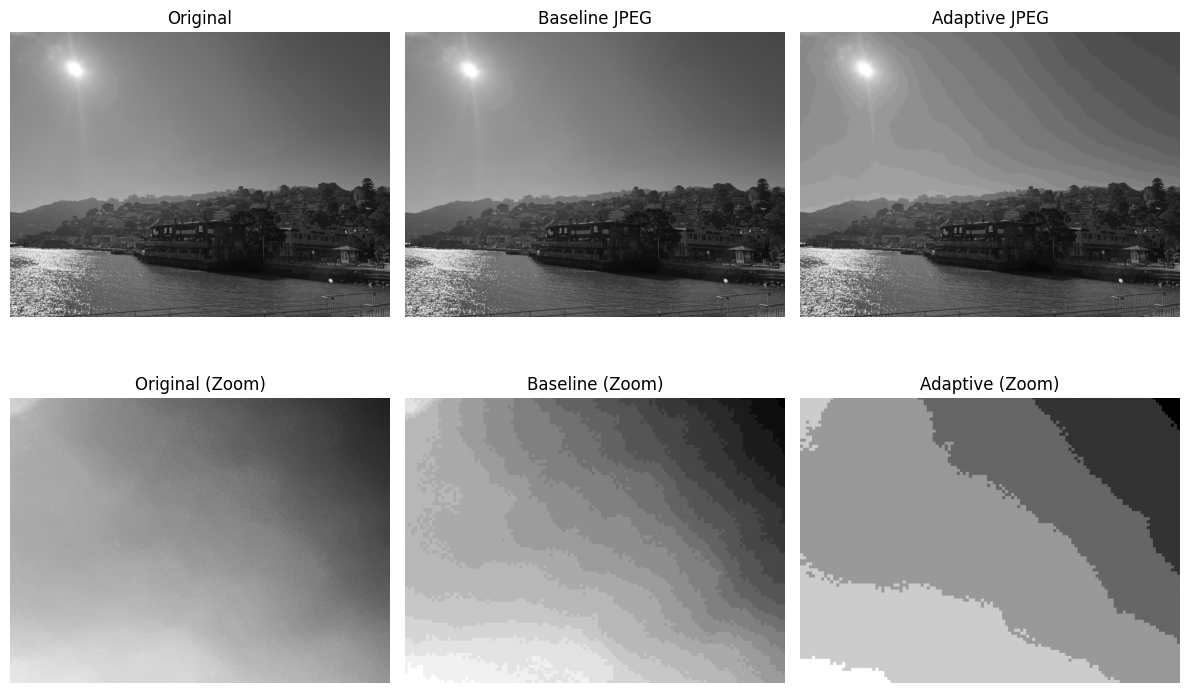

In [ ]:
# Load image
img = cv2.imread(
    '/content/saliency-image-compression/images/sample2.jpg',
    cv2.IMREAD_GRAYSCALE
)
img_padded = pad_to_block_size(img)

# Compress
baseline = baseline_compress(img_padded)
adaptive = adaptive_compress(img_padded, threshold=0.35)

# choosing a salient crop manually 
# (adjust these numbers if needed)
h, w = img_padded.shape
crop = img_padded[h//4:h//2, w//4:w//2]
crop_baseline = baseline[h//4:h//2, w//4:w//2]
crop_adaptive = adaptive[h//4:h//2, w//4:w//2]

# plotting
plt.figure(figsize=(12, 8))

# Top row
plt.subplot(2, 3, 1)
plt.imshow(img_padded, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(baseline, cmap='gray')
plt.title("Baseline JPEG")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(adaptive, cmap='gray')
plt.title("Adaptive JPEG")
plt.axis('off')

# Bottom row (zoomed)
plt.subplot(2, 3, 4)
plt.imshow(crop, cmap='gray')
plt.title("Original (Zoom)")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(crop_baseline, cmap='gray')
plt.title("Baseline (Zoom)")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(crop_adaptive, cmap='gray')
plt.title("Adaptive (Zoom)")
plt.axis('off')

plt.tight_layout()
plt.show()
